### Train Model
Train a Machine Learning Model and Evaluate its Performance (Classification & Regression)

In [1]:
%pip install matplotlib

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
)
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, accuracy_score, 
    precision_score, recall_score, f1_score, confusion_matrix,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

Note: you may need to restart the kernel to use updated packages.


### Load Dataset and Prepare Features

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

target_col = "Survived"
y = df[target_col].copy()
n_unique = y.nunique()

if y.dtype == "object" or n_unique == 2:
    task_type = "Binary Classification" if n_unique == 2 else "Multiclass Classification"
elif pd.api.types.is_integer_dtype(y) and 2 < n_unique <= 20:
    task_type = "Multiclass Classification"
else:
    task_type = "Regression"

feature_cols = [c for c in df.columns if c != target_col and c not in ["Name", "Ticket", "Cabin", "PassengerId"]]
X = df[feature_cols].copy()

for col in ["Sex"]:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X = pd.get_dummies(X, columns=["Embarked"], prefix=["Embarked"], drop_first=True, dtype=int)
X = X.fillna(X.median(numeric_only=True))

num_cols = X.select_dtypes(include="number").columns.tolist()
X[num_cols] = StandardScaler().fit_transform(X[num_cols])

stratify_col = y if task_type != "Regression" else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify_col,
)

print(f"Task Type: {task_type}")
print(f"Feature Count: {X.shape[1]}")
print(f"Train Samples: {X_train.shape[0]:,}")
print(f"Test Samples: {X_test.shape[0]:,}")

Task Type: Binary Classification
Feature Count: 8
Train Samples: 712
Test Samples: 179


### Select Model Family and Algorithm
- **Regression**: Linear
- **Classification**: Logistic Regression, KNN, SVM
- **Tree-Based**: Decision Tree, Random Forest, Gradient Boosting

In [3]:
algo = "random_forest_clf"

params = {
    "alpha": 1.0,
    "max_depth": 5,
    "n_estimators": 100,
    "n_neighbors": 5,
    "random_state": 42,
}

builders = {
    "linear_regression": lambda p: (LinearRegression(), "regression"),
    "logistic_regression": lambda p: (LogisticRegression(C=p["alpha"], max_iter=1000, random_state=p["random_state"]), "classification"),
    "knn": lambda p: (KNeighborsClassifier(n_neighbors=p["n_neighbors"]), "classification"),
    "svm": lambda p: (SVC(C=p["alpha"], random_state=p["random_state"]), "classification"),
    "decision_tree_reg": lambda p: (DecisionTreeRegressor(max_depth=p["max_depth"], random_state=p["random_state"]), "regression"),
    "random_forest_reg": lambda p: (RandomForestRegressor(n_estimators=p["n_estimators"], max_depth=p["max_depth"], random_state=p["random_state"], n_jobs=-1), "regression"),
    "gradient_boosting_reg": lambda p: (GradientBoostingRegressor(n_estimators=p["n_estimators"], max_depth=p["max_depth"], random_state=p["random_state"]), "regression"),
    "decision_tree_clf": lambda p: (DecisionTreeClassifier(max_depth=p["max_depth"], random_state=p["random_state"]), "classification"),
    "random_forest_clf": lambda p: (RandomForestClassifier(n_estimators=p["n_estimators"], max_depth=p["max_depth"], random_state=p["random_state"], n_jobs=-1), "classification"),
    "gradient_boosting_clf": lambda p: (GradientBoostingClassifier(n_estimators=p["n_estimators"], max_depth=p["max_depth"], random_state=p["random_state"]), "classification"),
}

model, model_kind = builders[algo](params)
print(f"Algorithm: {algo}")
print(f"Model Kind: {model_kind}")
print(f"Estimator: {model}")

Algorithm: random_forest_clf
Model Kind: classification
Estimator: RandomForestClassifier(max_depth=5, n_jobs=-1, random_state=42)


### Train - Fit the Model

In [4]:
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

### Evaluate - Train vs Test Metrics

- **Regression**: R², MAE, MSE, RMSE
- **Classification**: Accuracy, Precision, Recall, F1

In [5]:
def score_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "R^2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
    }

def score_classification(y_true, y_pred):
    avg = "binary" if len(np.unique(y_true)) == 2 else "weighted"
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average=avg, zero_division=0),
        "Recall": recall_score(y_true, y_pred, average=avg, zero_division=0),
        "F1": f1_score(y_true, y_pred, average=avg, zero_division=0),
    }

scorer = score_regression if model_kind == "regression" else score_classification
train_metrics = scorer(y_train, y_pred_train)
test_metrics = scorer(y_test, y_pred_test)

metrics_df = pd.DataFrame({"Train": train_metrics, "Test": test_metrics})
metrics_df["Delta (Train - Test)"] = metrics_df["Train"] - metrics_df["Test"]
metrics_df.round(4)

,Train,Test,Delta (Train - Test)
Accuracy,0.8638,0.8045,0.0593
Precision,0.9151,0.8542,0.0609
Recall,0.7106,0.5942,0.1164
F1,0.8000,0.7009,0.0991


### Overfitting Check

Large Positive Gap Between Train & Test on the Headline Metric Usually means the Model is Overfitting!

In [6]:
headline = "R^2" if model_kind == "regression" else "Accuracy"
gap = train_metrics[headline] - test_metrics[headline]

print(f"Headline Metric: {headline}")
print(f"Train: {train_metrics[headline]:.4f}")
print(f"Test: {test_metrics[headline]:.4f}")
print(f"Train/Test Gap: {gap:+.3f}")

Headline Metric: Accuracy
Train: 0.8638
Test: 0.8045
Train/Test Gap: +0.059


### Train vs Test Comparison Chart

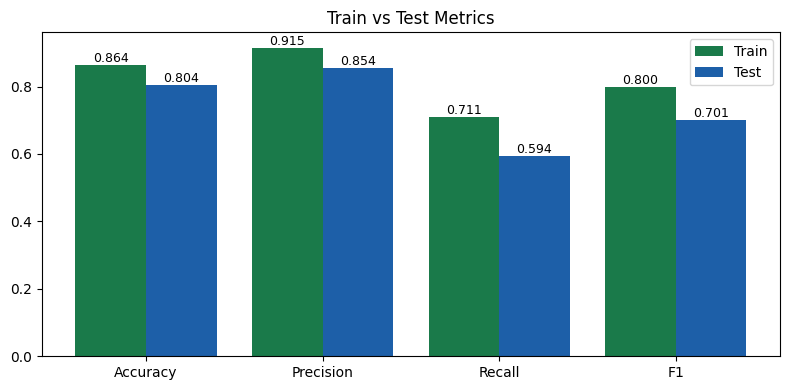

In [7]:
names = list(train_metrics.keys())
train_vals = [train_metrics[n] for n in names]
test_vals = [test_metrics[n] for n in names]
x = np.arange(len(names))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - 0.4/2, train_vals, 0.4, label="Train", color="#1A7A4A")
ax.bar(x + 0.4/2, test_vals, 0.4, label="Test", color="#1D5FA8")

for i, v in enumerate(train_vals):
    ax.text(i - 0.4/2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
for i, v in enumerate(test_vals):
    ax.text(i + 0.4/2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_title("Train vs Test Metrics")
ax.legend()
plt.tight_layout()
plt.show()

### Diagnostic Plot

- **Classification**: Confusion Matrix
- **Regression**: Predicted vs Actual Scatter /w Ideal Line

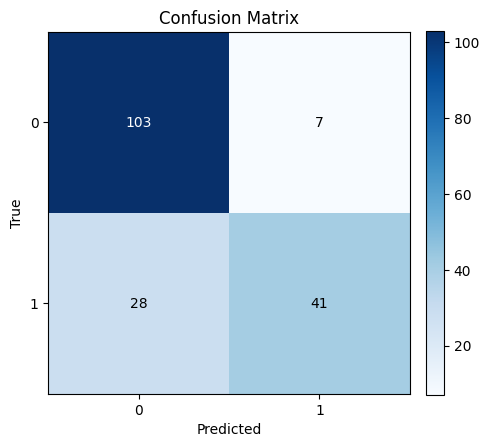

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))

if model_kind == "classification":
    labels = sorted(np.unique(np.concatenate([np.asarray(y_test), np.asarray(y_pred_test)])).tolist())
    cm = confusion_matrix(y_test, y_pred_test, labels=labels)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Confusion Matrix")
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

else:
    y_true_arr = np.asarray(y_test, dtype=float)
    y_pred_arr = np.asarray(y_pred_test, dtype=float)
    lo = float(min(y_true_arr.min(), y_pred_arr.min()))
    hi = float(max(y_true_arr.max(), y_pred_arr.max()))
    ax.scatter(y_true_arr, y_pred_arr, alpha=0.6, color="#1D5FA8")
    ax.plot([lo, hi], [lo, hi], "--", color="#C0392B", label="Ideal (y = x)")
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
    ax.set_title("Predicted vs Actual")
    ax.legend()

plt.tight_layout()
plt.show()

### Cross-Validation

Run k-fold Cross-Validation on the Training Set to Check Stability of the Accuracy Metric Across Folds!

Cross-Validation Scoring: accuracy
Folds: 5
Fold Scores: [0.8112, 0.7762, 0.8662, 0.8592, 0.8099]
Mean ± Std: 0.8245 +/- 0.0337


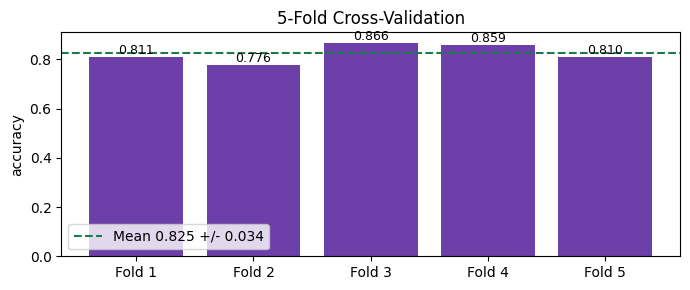

In [9]:
cv_folds = 5
cv_scoring = "r2" if model_kind == "regression" else "accuracy"
scores = cross_val_score(model, X_train, y_train, cv=cv_folds, scoring=cv_scoring, n_jobs=-1)

print(f"Cross-Validation Scoring: {cv_scoring}")
print(f"Folds: {cv_folds}")
print(f"Fold Scores: {np.round(scores, 4).tolist()}")
print(f"Mean ± Std: {scores.mean():.4f} +/- {scores.std():.4f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar([f"Fold {i+1}" for i in range(len(scores))], scores, color="#6D3FA8")
ax.axhline(scores.mean(), linestyle="--", color="#1A7A4A", label=f"Mean {scores.mean():.3f} +/- {scores.std():.3f}")

for i, v in enumerate(scores):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel(cv_scoring)
ax.set_title(f"{cv_folds}-Fold Cross-Validation")
ax.legend()
plt.tight_layout()
plt.show()